# cfdvv Python API Demo

**cfdvv — CFD Verification & Validation Suite**

This notebook demonstrates the **cfdvv** Python API — no CLI needed.

What you will learn:
- Browse and inspect test cases
- Compare simulation results against reference data
- Generate comparison plots and display them inline
- Compute error norms (L1, L2, Linf, Relative L2)
- Perform Grid Convergence Index (GCI) analysis
- Read and manipulate CSV/VTK data

**Prerequisites:** `pip install cfdvv` (all 51 test cases are bundled).

## 1. Setup

In [1]:
!pip install -q cfdvv pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.6 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
from IPython.display import Image, HTML, display

import cfdvv
from cfdvv.compare import compare_case
from cfdvv.readers import read_file
from cfdvv.plot import plot_comparison
from cfdvv.gci import compute_gci
from cfdvv.norms import l1_norm, l2_norm, linf_norm, relative_l2_norm, compute_all_norms
from cfdvv.schema import load_case_yaml

# Where cases live inside the installed package
CFDVV_DIR = os.path.dirname(cfdvv.__file__)
CASES = os.path.join(CFDVV_DIR, 'cases')

print(f"cfdvv {cfdvv.__version__}  |  cases: {CASES}")

cfdvv 0.5.0  |  cases: /usr/local/lib/python3.12/dist-packages/cfdvv/cases


## 2. Browse Available Cases

Scan for `case.yaml` files and build a quick overview table.

In [4]:
import glob

rows = []
for yf in sorted(glob.glob(os.path.join(CASES, '**', 'case.yaml'), recursive=True)):
    case = load_case_yaml(os.path.dirname(yf))
    rows.append({
        'ID':        case['id'],
        'Category':  f"{case['category']}/{case.get('subcategory', '')}",
        'Dim':       case['dimension'],
        'Reference': case['reference']['type'],
        'Tags':      ', '.join(case.get('tags', [])[:3]),
    })

df = pd.DataFrame(rows)
display(HTML(f'<b>{len(df)} cases found.</b>'))
df.head(12)

,ID,Category,Dim,Reference,Tags
0,cfdbench-couette,validation/turbulent,2D,experimental,"newtonian, laminar, steady"
1,cfdbench-poiseuille,validation/turbulent,2D,experimental,"newtonian, laminar, steady"
2,ercoftac-bfs-laminar,validation/turbulent,2D,experimental,"newtonian, laminar, separation"
3,exactpack-sod,validation/turbulent,1D,experimental,"compressible, inviscid, unsteady"
4,jhtdb-channel180,validation/turbulent,3D,experimental,"newtonian, turbulent, channel"
5,masa-ns-2d,validation/turbulent,2D,experimental,"mms, manufactured-solution, newtonian"
6,nasa-tmr-flatplate,validation/turbulent,2D,experimental,"newtonian, turbulent, boundary-layer"
7,ahmed-body-25,validation/complex-geometry,3D,experimental,"newtonian, turbulent, automotive"
8,ahmed-body-35,validation/complex-geometry,3D,experimental,"newtonian, turbulent, automotive"
9,cylinder-viv-3d,validation/complex-geometry,3D,experimental,"newtonian, laminar, viv"


In [5]:
# Filter to verification cases only
df[df['Category'].str.startswith('verification')][['ID', 'Dim', 'Reference']].head(8)

,ID,Dim,Reference
31,double-mach-reflection,2D,analytical
32,oblique-shock-3d,3D,analytical
33,oblique-shock,2D,analytical
34,sod-shock-tube,1D,analytical
35,beltrami-flow-3d,3D,analytical
36,couette-2d,2D,analytical
37,couette-3d,3D,analytical
38,flat-plate-blausius-3d,3D,analytical


## 3. Inspect a Case

Load a case YAML to see physics, mesh requirements, tolerances, expected quantities.

In [6]:
CASE_DIR = os.path.join(CASES, 'verification', 'incompressible', 'poiseuille-2d')
case = load_case_yaml(CASE_DIR)

print(f"Case:  {case['name']} ({case['id']})")
print(f"Dim:   {case['dimension']}")
print(f"Ref:   {case['reference']['type']} — {case['reference']['source']}")
print(f"Soln:  {case['reference']['solution']}")
print(f"Mesh:  {case['mesh']['type']}, recommended {case['mesh']['recommended']}")
print(f"Tolerances: {case.get('tolerances', {})}")
print(f"Quantities:")
for q in case['quantities']:
    print(f"  {q['name']}: type={q['type']}, norm={q.get('norm', 'L2')}")

Case:  Plane Poiseuille Flow (2D) (poiseuille-2d)
Dim:   2D
Ref:   analytical — White, F.M. Viscous Fluid Flow, 3rd ed., McGraw-Hill, 2006
Soln:  u(y) = (G/(2*mu)) * y * (H - y), v = 0, p(x) = p0 - G*x
Mesh:  uniform quadrilateral, recommended [10, 20]
Tolerances: {'L2': 1e-06, 'Linf': 1e-05}
Quantities:
  u: type=profile, norm=L2
  v: type=profile, norm=L2


## 4. Compare Results Against Reference

`compare_case()` matches your simulation data against the analytical reference and computes error norms.

We self-compare the analytical solution as a sanity check: all errors should be zero.

In [7]:
REF_CSV = os.path.join(CASE_DIR, 'reference', 'analytical', 'solution.csv')

result = compare_case(CASE_DIR, REF_CSV, norm_type='L2', tolerance=1e-10)

table_rows = []
for fr in result['field_results']:
    if 'error' in fr:
        table_rows.append([fr['field'], 'ERROR', fr['error'], '-', '-', 'FAIL'])
    else:
        an = fr.get('all_norms', {})
        status = 'PASS' if fr.get('passed', True) else 'FAIL'
        table_rows.append([
            fr['field'], fr.get('norm_type', '-'),
            f"{fr['norm_value']:.6e}",
            f"{an.get('L1', 0):.6e}",
            f"{an.get('Linf', 0):.6e}",
            f"{an.get('Relative_L2', 0):.6e}",
            status,
        ])

rdf = pd.DataFrame(table_rows, columns=['Field', 'Norm', 'Value', 'L1', 'Linf', 'Rel.L2', 'Status'])
display(rdf)
display(HTML('<h3 style="color:#155724;background:#d4edda;padding:10px;border-radius:4px">PASSED — all errors zero</h3>'))

,Field,Norm,Value,L1,Linf,Rel.L2,Status
0,u,L2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,PASS
1,v,L2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,PASS


### Compare with bad (noisy) data

In [8]:
import tempfile

# Synthesize noisy data on the same grid
ref_data, ref_cols = read_file(REF_CSV)
noisy = ref_data.copy()
noisy[:, 1] += np.random.normal(0, 0.01, noisy.shape[0])  # add noise to u

bad_csv = os.path.join(tempfile.gettempdir(), 'bad_demo.csv')
np.savetxt(bad_csv, noisy, delimiter=',', header=','.join(ref_cols), comments='', fmt='%s')

bad_r = compare_case(CASE_DIR, bad_csv, norm_type='L2', tolerance=1e-6)
for fr in bad_r['field_results']:
    if 'error' not in fr:
        status = 'PASS' if fr.get('passed', False) else 'FAIL'
        print(f"  {fr['field']}: {fr['norm_type']} = {fr['norm_value']:.6e}  [{status}]")

display(HTML('<h3 style="color:#721c24;background:#f8d7da;padding:10px;border-radius:4px">FAILED — noisy data</h3>'))

  u: L2 = 9.608520e-03  [FAIL]
  v: L2 = 0.000000e+00  [PASS]


## 5. Generate Comparison Plots

`plot_comparison()` produces profile + scatter panels. Display them inline with `IPython.display.Image`.

Saved: poiseuille-2d_u.png


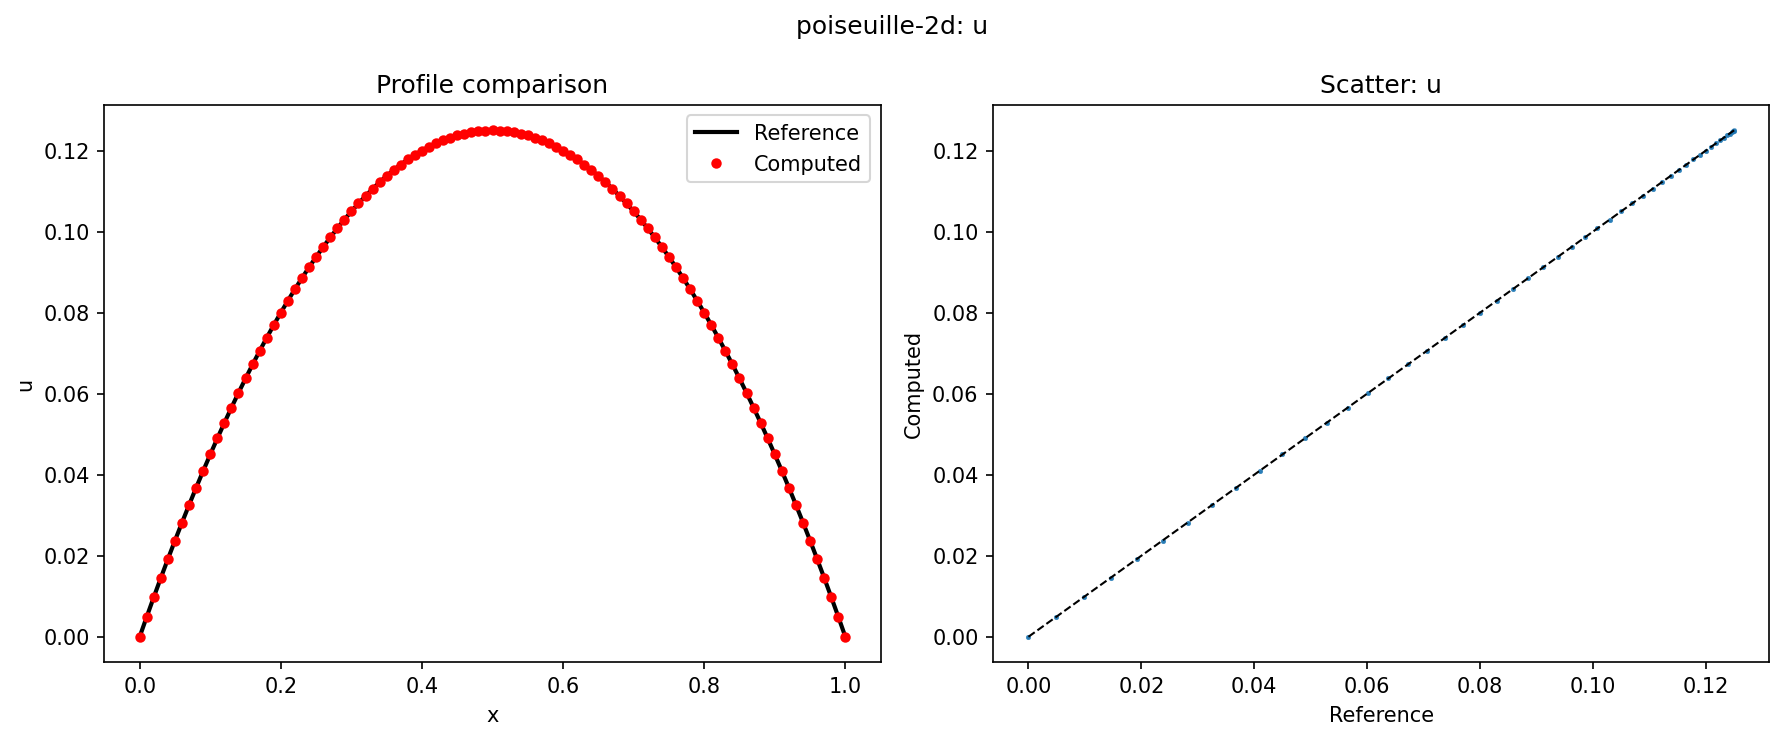

Saved: poiseuille-2d_v.png


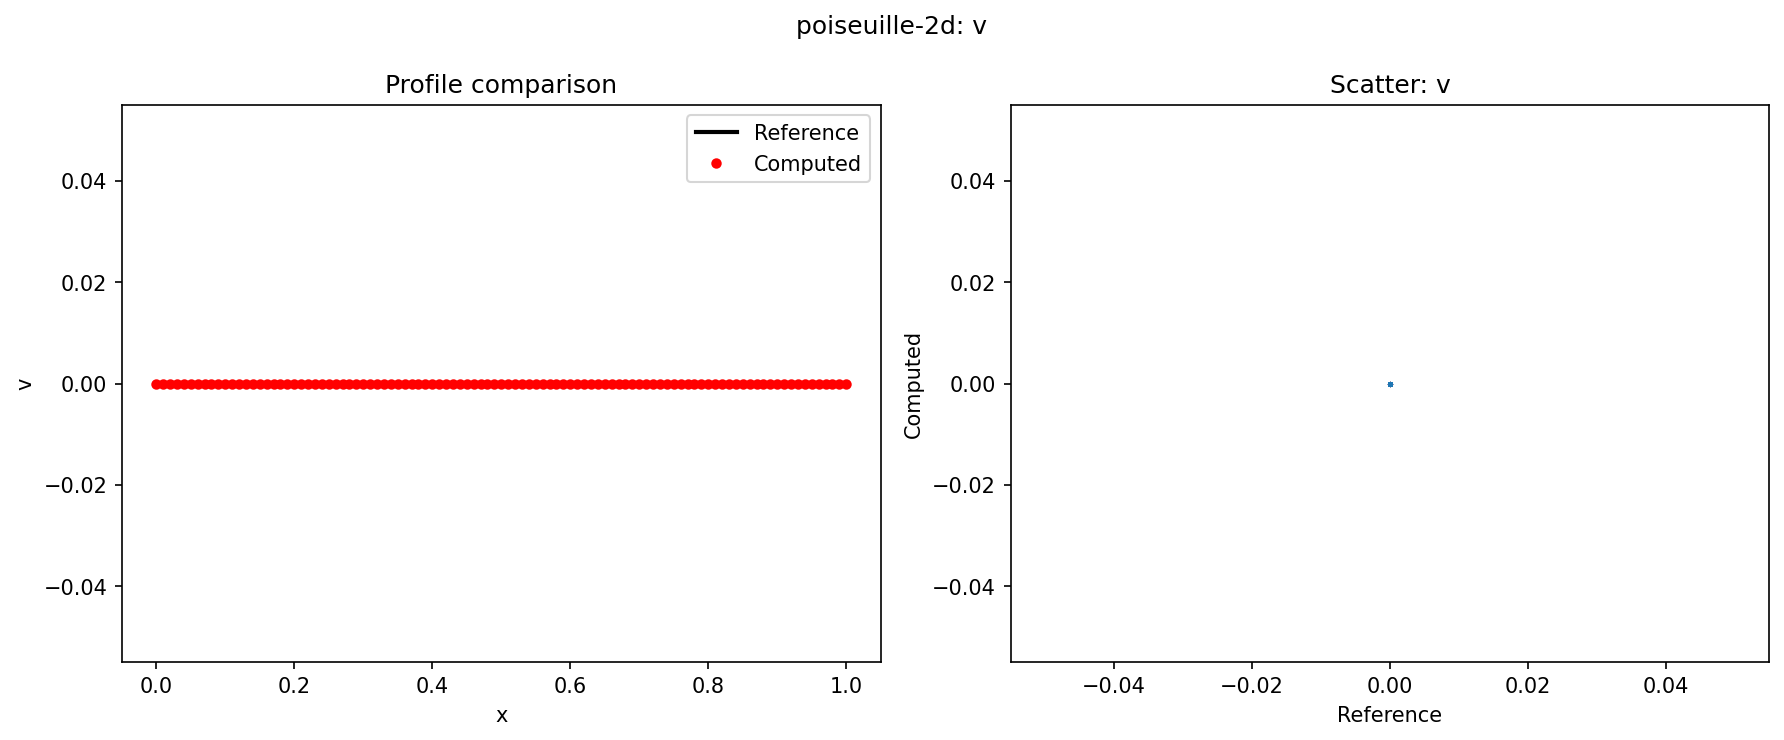

In [9]:
plot_dir = tempfile.mkdtemp(prefix='cfdvv_demo_')

for field in ['u', 'v']:
    fp = plot_comparison(REF_CSV, ref_data, ref_cols,
                         field_name=field, output_dir=plot_dir, case_id='poiseuille-2d')
    print(f'Saved: {os.path.basename(fp)}')
    display(Image(fp))

## 6. Grid Convergence Index (GCI)

Estimate the asymptotic value via Richardson extrapolation using 3 mesh levels.

In [10]:
# Synthesize coarse/medium/fine results from the analytical solution
def make_result(n_pts, seed=0):
    ys = np.linspace(0, 1, n_pts)
    us = 5.0 * ys * (1 - ys)  # analytical parabola scaled so L2 decreases with grid
    vs = np.zeros_like(ys)
    csv_path = os.path.join(tempfile.gettempdir(), f'gci_{n_pts:02d}.csv')
    np.savetxt(csv_path, np.column_stack([ys, us, vs]),
               delimiter=',', header='y,u,v', comments='', fmt='%s')
    return csv_path

gci_result = compute_gci(
    CASE_DIR,
    [make_result(6), make_result(11), make_result(21)],
    mesh_sizes=[0.05, 0.025, 0.0125],
)

if 'error' in gci_result:
    print(f"Error: {gci_result['error']}")
else:
    print(f"Mesh sizes: {gci_result['mesh_sizes']}")
    print(f"Refinement: {gci_result['refinement_ratios']}")
    for qr in gci_result['quantity_results']:
        print(f"\nQuantity {qr['quantity_index']}:")
        print(f"  f1={qr['f1']:.8f}  f2={qr['f2']:.8f}  f3={qr['f3']:.8f}")
        print(f"  Order p = {qr['order_p']}")
        if qr['extrapolated_value'] is not None:
            print(f"  Extrapolated = {qr['extrapolated_value']:.8f}")
        if qr['gci21'] is not None:
            print(f"  GCI = {qr['gci21']:.6f}")

Mesh sizes: [0.05, 0.025, 0.0125]
Refinement: [2.0, 2.0]

Quantity 0:
  f1=0.78730857  f2=0.81001289  f3=0.81568979
  Order p = 1.999789874695252
  Extrapolated = 0.77973900
  GCI = 0.012018

Quantity 1:
  f1=0.00000000  f2=0.00000000  f3=0.00000000
  Order p = inf
  Extrapolated = 0.00000000


## 7. Direct Error Norms

In [11]:
computed  = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
reference = np.array([1.1, 1.9, 3.2, 3.8, 5.1])

norms = compute_all_norms(computed, reference)
for name in ['L1', 'L2', 'Linf', 'Relative_L2']:
    print(f"{name:>12s}: {norms[name]:.4e}")

          L1: 1.4000e-01
          L2: 1.4832e-01
        Linf: 2.0000e-01
 Relative_L2: 4.4515e-02


## 8. Read Data Files

`read_file()` handles CSV, VTK/VTU, and OpenFOAM formats.

In [12]:
data, cols = read_file(REF_CSV)
print(f"Shape: {data.shape}   Columns: {cols}")
print(f"First 3 rows:\n{data[:3]}")
print(f"u range: [{data[:, 1].min():.4f}, {data[:, 1].max():.4f}]")

Shape: (101, 3)   Columns: ['y', 'u', 'v']
First 3 rows:
[[0.      0.      0.     ]
 [0.01    0.00495 0.     ]
 [0.02    0.0098  0.     ]]
u range: [0.0000, 0.1250]


## 9. Workflow with Your Own Data

```python
# 1. Export your simulation results as CSV
#    Header: x,y,u,v,p  (or x,y,z,u,v,w,p,T,rho,Cp,Cf)

# 2. Compare against a case
result = compare_case(
    case_dir,           # path to case directory (see _find_cases_root)
    'my_results.csv',   # your CSV file
    norm_type='L2',
    tolerance=1e-4,
)

# 3. Generate plots
ref_data, ref_cols = read_file(case_dir + '/reference/analytical/solution.csv')
for field in ['u', 'v', 'p']:
    path = plot_comparison('my_results.csv', ref_data, ref_cols,
                           field_name=field, output_dir='plots',
                           case_id='my_case')
    display(Image(path))
```

## 10. Summary

| Feature | API call |
|---------|----------|
| List cases | `glob(cases_dir + '/**/case.yaml')` + `load_case_yaml()` |
| Inspect case | `load_case_yaml(case_dir)` |
| Compare | `compare_case(case_dir, result_csv, norm_type, tolerance)` |
| Plot | `plot_comparison(result, ref_data, ref_cols, field, dir, id)` |
| GCI | `compute_gci(case_dir, [coarse,med,fine], mesh_sizes)` |
| Norms | `l2_norm()`, `l1_norm()`, `linf_norm()`, `relative_l2_norm()` |
| Read data | `read_file(filepath)` |

See also:
- [CLI Quick Start](https://vvp-cfd.github.io/cfd-vv-suite/getting-started.html)
- [Jupyter Guide](https://vvp-cfd.github.io/cfd-vv-suite/jupyter-guide.html)
- [Case Index](https://vvp-cfd.github.io/cfd-vv-suite/case-index.html)